# Theory

When atoms come together to form molecules, their atomic orbitals combine to form molecular orbitals. The arrangement and energy levels of electrons within these molecular orbitals dictate the properties of the resulting molecule and the strength of the chemical bonds. For instance, in the formation of a hydrogen molecule (H2) from two individual hydrogen atoms, the electron from each atom occupies atomic orbitals. As the atoms approach each other, these atomic orbitals overlap and combine to form new molecular orbitals — one with lower energy **(a bonding orbital)** and one with higher energy **(an anti-bonding orbital)**. 

The two electrons, one from each hydrogen atom, will preferentially occupy the lower-energy bonding orbital, leading to the formation of a stable covalent bond that holds the H2 molecule together. The energy difference between the separated atoms and the formed molecule, particularly the energy of the electrons in the molecular orbitals, determines the stability and properties of the bond.

---

We want to simulate $H_2$ on a quantum computer. The first step is to recognize that a molecule is not just a static arangement of atoms but rather a collection of electrons moving in the electric field of nuclei. The electrons will experience a Coulomb force of attraction to the nuclei and a repulsive force between each other. 

## Second quantization:

We use second quantization to describe the energies of the electrons. This is made up of two parts:

1. **Single-electron terms**: energy of an electron in an orbital, including kinetic energy and attraction to nuclei.

2. **Two-electron terms**: repulsion between pairs of electrons in different orbitals.

$$H = \sum_{p,q} h_{pq}\, a_p^\dagger a_q + \frac{1}{2} \sum_{p,q,r,s} h_{pqrs}\, a_p^\dagger a_q^\dagger a_r a_s$$


Physical interpretation:

$a_p^\dagger a_p \rightarrow$ electron sitting in orbital p

$a_p^\dagger a_q \rightarrow$ electron hopping from orbital p to orbital q

$a_p^\dagger a_q^\dagger a_r a_s \rightarrow$ electron-electron repulsion

The coefficients $h_{pq}$ and $h_{pqrs}$ are one and two-electron overlap intergrals, containing all the physical information about the molecule. 

### 1️⃣ One-electron integrals $(h_{pq}$)

* These describe the energy of a single electron moving in the **field of the nuclei**.  

* Mathematically, they are written as:  

$$
h_{pq} = \int \chi_p^*(\mathbf{r}) \left( -\frac{1}{2}\nabla^2 - \sum_A \frac{Z_A}{|\mathbf{r}-\mathbf{R}_A|} \right) \chi_q(\mathbf{r}) \, d\mathbf{r}
$$

* **Interpretation:**
  * $Z_A$ is the proton number  
  * Diagonal ($p = q$) → energy of an electron sitting in orbital \(p\)  
  * Off-diagonal ($p \neq q$) → “hopping” energy — how likely an electron can move from orbital \(q\) to \(p\)  

---

### 2️⃣ Two-electron integrals $(h_{pqrs}$)

* These describe **electron-electron repulsion**, i.e., how the presence of one electron affects another:  

$$
h_{pqrs} = \int \int \frac{\chi_p^*(\mathbf{r}_1) \chi_q^*(\mathbf{r}_2) \chi_r(\mathbf{r}_1) \chi_s(\mathbf{r}_2)}{|\mathbf{r}_1 - \mathbf{r}_2|} \, d\mathbf{r}_1 \, d\mathbf{r}_2
$$

* **Interpretation:**  
  * Measures the Coulomb repulsion between electrons in orbitals $(p,r)$ and $(q,s)$  
  * Larger values → stronger repulsion, contributing more to the total energy  
 

---

### The role of the basis set

We now hit a practical problem: how do we **compute these integrals**? We need to know the shapes of the orbitals $\chi_p$ and $\chi_q$. This is where a **basis set** comes in.

* A **basis set** is a predefined set of functions (atomic-like orbitals) that we use to expand the molecular orbitals.  

* Common choices:  
  * **Slater-type orbitals (STO):** decay like true atomic orbitals, very accurate but harder to integrate  
  * **Gaussian-type orbitals (GTO):** decay like $e^{-\alpha r^2}$, much easier to integrate analytically  
  * **STO-nG:** approximate Slater orbitals using $n$ Gaussians (e.g., STO-6G)  

* By choosing a basis set, we **reduce the problem of computing integrals over continuous space to computing integrals over known functions**. This is what allows software like PySCF or Psi4 to output the $h_{pq}$ and $h_{pqrs}$ **numerically**.  



## Mapping from Fermions to Qubits: Jordan-Wigner Transformation

So far, we have the second-quantized Hamiltonian:

$$
H = \sum_{p,q} h_{pq}\, a_p^\dagger a_q 
    + \frac{1}{2} \sum_{p,q,r,s} h_{pqrs}\, a_p^\dagger a_q^\dagger a_r a_s
$$

Here, $a_p^\dagger$ and $a_p$ are **fermionic operators**. They follow anti-commutation rules:

$$
\{ a_p, a_q^\dagger \} = \delta_{pq}, \quad \{ a_p, a_q \} = 0
$$

Quantum computers, however, work with **qubits**, which do **not naturally obey fermionic statistics**. We need a way to represent fermionic creation and annihilation operators as qubit operators while **preserving these anti-commutation rules**. This is where the **Jordan-Wigner (JW) mapping** comes in.

---

### 4.1 The idea of the JW mapping

* Each **qubit represents a spin-orbital**:  
  * $|0\rangle$ → orbital is empty  
  * $|1\rangle$ → orbital is occupied  

* The **JW mapping** translates the fermionic operators into **Pauli matrices**:

$$
a_p^\dagger \mapsto \frac{X_p - i Y_p}{2} \otimes Z_0 Z_1 \dots Z_{p-1}, \quad
a_p \mapsto \frac{X_p + i Y_p}{2} \otimes Z_0 Z_1 \dots Z_{p-1}
$$

* The **string of Z operators** keeps track of the **fermionic sign**: whenever we swap fermions, we pick up a minus sign.  

---

### 4.2 Physical interpretation

* After mapping:  
  * **Z operators** measure occupation of an orbital  
  * **XX + YY combinations** correspond to electron hopping/exchange between orbitals  
  * **ZZ combinations** capture electron-electron interactions  

* **Crucial point:** The JW mapping **does not change the physics** — it just rewrites the Hamiltonian in a language that qubits understand.  

---

### 4.3 Example: one-electron term

Consider the diagonal term $a_0^\dagger a_0$ (electron in orbital 0). Under JW:

$$
a_0^\dagger a_0 \mapsto \frac{1 - Z_0}{2}
$$

* The coefficient $h_{00}$ from the one-electron integral remains the same.  
* The operator now **measures whether qubit 0 is in state $|1\rangle$**, corresponding to the orbital being occupied.  

Similarly, an off-diagonal hopping term $a_0^\dagger a_1 + a_1^\dagger a_0$ maps to:

$$
a_0^\dagger a_1 + a_1^\dagger a_0 \mapsto \frac{1}{2} \left( X_0 X_1 + Y_0 Y_1 \right)
$$

* This captures the **quantum mechanical possibility of electrons exchanging between orbitals**.  

---

### H₂ Hamiltonian in 4‑qubit Jordan‑Wigner form

Below is the molecular Hamiltonian for the H₂ molecule in a **4‑qubit Jordan–Wigner encoding in an STO‑6G (minimal) basis**. Each term is a Pauli string multiplied by a real coefficient, derived from the one‑ and two‑electron integrals:

$$
\begin{aligned}
H_{\text{H}_2} = & \;\alpha_0\, I\!I\!I\!I 
+ \alpha_1\, Z_0 
+ \alpha_2\, Z_1 
+ \alpha_3\, Z_2 
+ \alpha_4\, Z_3 \\
&+ \alpha_5\, Z_0Z_1
+ \alpha_6\, Z_0Z_2
+ \alpha_7\, Z_1Z_2
+ \alpha_8\, Z_0Z_3
+ \alpha_9\, Z_1Z_3
+ \alpha_{10}\, Z_2Z_3 \\
&+ \alpha_{11}\, Y_0 Y_1 X_2 X_3
+ \alpha_{12}\, X_0 Y_1 Y_2 X_3
+ \alpha_{13}\, Y_0 X_1 X_2 Y_3
+ \alpha_{14}\, X_0 X_1 Y_2 Y_3.
\end{aligned}
$$

Here:
* $I\!I\!I\!I$ is the identity on all four qubits.  
* $Z_i$, $X_i$, $Y_i$ are Pauli operators acting on qubit $i$ (with $0$ the least significant qubit).  
* Terms like $Z_0Z_1$ mean $Z$ on qubit 0 and $Z$ on qubit 1 (identity on 2 and 3).  

The $\alpha_j$ coefficients are **real numbers** that come from evaluating the integrals $h_{pq}$ and $h_{pqrs}$ for a chosen internuclear distance (typically near equilibrium). They encode all the physics of the molecule and are exactly the ones you feed into VQE.

In code (e.g. Qiskit), this would be represented as a list of Pauli strings with coefficients, e.g.:



# Step 1: Building the problem Hamiltonian

First we need to build the electronic Hamiltonian for the $H_2$ molecule and map it from its fermionic representation to a qubit operator than can be executed on a quantum computer.

First, we use PySCFDriver from Qiskit Nature to perform a classical electronic structure calculation. This computes the molecular integrals for two hydrogen atoms separated by 0.735 Å using the STO-6G basis set. The result contains the second-quantized electronic Hamiltonian expressed in terms of fermionic creation and annihilation operators.

In [75]:
from qiskit_nature.second_q.drivers import PySCFDriver

driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.735",
    basis="sto3g",  # minimal basis
)
problem = driver.run()
fermionic_op = problem.hamiltonian.second_q_op()
print(fermionic_op)

Fermionic Operator
number spin orbitals=4, number terms=36
  -1.25633907300325 * ( +_0 -_0 )
+ -0.471896007281142 * ( +_1 -_1 )
+ -1.25633907300325 * ( +_2 -_2 )
+ -0.471896007281142 * ( +_3 -_3 )
+ 0.3378550774017582 * ( +_0 +_0 -_0 -_0 )
+ 0.3322908651276483 * ( +_0 +_1 -_1 -_0 )
+ 0.3378550774017582 * ( +_0 +_2 -_2 -_0 )
+ 0.3322908651276483 * ( +_0 +_3 -_3 -_0 )
+ 0.09046559989211571 * ( +_0 +_0 -_1 -_1 )
+ 0.09046559989211571 * ( +_0 +_1 -_0 -_1 )
+ 0.09046559989211571 * ( +_0 +_2 -_3 -_1 )
+ 0.09046559989211571 * ( +_0 +_3 -_2 -_1 )
+ 0.09046559989211571 * ( +_1 +_0 -_1 -_0 )
+ 0.09046559989211571 * ( +_1 +_1 -_0 -_0 )
+ 0.09046559989211571 * ( +_1 +_2 -_3 -_0 )
+ 0.09046559989211571 * ( +_1 +_3 -_2 -_0 )
+ 0.3322908651276483 * ( +_1 +_0 -_0 -_1 )
+ 0.3492868613660083 * ( +_1 +_1 -_1 -_1 )
+ 0.3322908651276483 * ( +_1 +_2 -_2 -_1 )
+ 0.3492868613660083 * ( +_1 +_3 -_3 -_1 )
+ 0.3378550774017582 * ( +_2 +_0 -_0 -_2 )
+ 0.3322908651276483 * ( +_2 +_1 -_1 -_2 )
+ 0.3378550774017582 

This operator is still written in terms of fermionic operators, which cannot be directly executed on qubits.

To make the Hamiltonian compatible with a quantum circuit, we apply the Jordan–Wigner transformation. This maps the occupation of spin-orbitals to qubits:

In [76]:
from qiskit_nature.second_q.mappers import JordanWignerMapper

mapper = JordanWignerMapper()
qubit_jw_op = mapper.map(fermionic_op)

for pauli, coeff in qubit_jw_op.to_list():
    print(f"{pauli}  {coeff.real}")

IIII  -0.8105479805373281
IIIZ  0.1721839326191555
IIZI  -0.22575349222402363
IZII  0.17218393261915538
ZIII  -0.22575349222402363
IIZZ  0.1209126326177663
IZIZ  0.1689275387008791
ZIIZ  0.16614543256382416
YYYY  0.04523279994605785
XXYY  0.04523279994605785
YYXX  0.04523279994605785
XXXX  0.04523279994605785
IZZI  0.16614543256382416
ZIZI  0.17464343068300414
ZZII  0.1209126326177663


A different mapping we could use is the Parity Mapper. Instead of encoding each spin-orbital into its own qubit, it stores the cumulative parity where each qubit stores a 0 for even parity, and 1 for odd parity. Because the total number of electrons in the system is fixed, some qubits are completely determined and can be removed, allowing us to use fewer qubits while still fully representing the system.

In [77]:
from qiskit_nature.second_q.mappers import ParityMapper

mapper = ParityMapper(num_particles=problem.num_particles)
qubit_p_op = mapper.map(fermionic_op)

for pauli, coeff in qubit_p_op.to_list():
    print(f"{pauli}  {coeff.real}")

II  -1.0523732457728605
IZ  0.39793742484317896
ZI  -0.39793742484317884
ZZ  -0.011280104256234907
XX  0.1809311997842313


### For those of you on Windows, PySCFDriver will not work with using WSL so I have created the qubit lists manually

In [151]:
from qiskit.quantum_info import SparsePauliOp

qubit_jw_op = SparsePauliOp.from_list([
    ('IIII', -0.8105479805373281),
    ('IIIZ',  0.1721839326191555),
    ('IIZI', -0.22575349222402363),
    ('IZII',  0.17218393261915538),
    ('ZIII', -0.22575349222402363),
    ('IIZZ',  0.1209126326177663),
    ('IZIZ',  0.1689275387008791),
    ('ZIIZ',  0.16614543256382416),
    ('YYYY',  0.04523279994605785),
    ('XXYY',  0.04523279994605785),
    ('YYXX',  0.04523279994605785),
    ('XXXX',  0.04523279994605785),
    ('IZZI',  0.16614543256382416),
    ('ZIZI',  0.17464343068300414),
    ('ZZII',  0.1209126326177663),
])

qubit_p_op = SparsePauliOp.from_list([
    ('II', -1.0523732457728605),
    ('IZ',  0.39793742484317896),
    ('ZI', -0.39793742484317884),
    ('ZZ', -0.011280104256234907),
    ('XX',  0.1809311997842313),
])

# Exact solution

In [152]:
from qiskit.quantum_info import SparsePauliOp
import numpy as np

h2_hamiltonian = SparsePauliOp.from_list(qubit_p_op.to_list())
 
# exact ground state energy of hamiltonian
nuclear_repulsion = 0.71997
A = np.array(h2_hamiltonian)
eigenvalues, eigenvectors = np.linalg.eig(A)
print("Electronic ground state energy (Hartree): ", min(eigenvalues).real)
print("Nuclear repulsion energy (Hartree): ", nuclear_repulsion)
print(
    "Total ground state energy (Hartree): ", min(eigenvalues).real + nuclear_repulsion
)
h2 = min(eigenvalues).real + nuclear_repulsion

Electronic ground state energy (Hartree):  -1.8572750302023795
Nuclear repulsion energy (Hartree):  0.71997
Total ground state energy (Hartree):  -1.1373050302023795


# Step 2: Build an ansatz

Now that we have a Hamiltonian, we want to find its ground state. To do this, we prepare trial quantum states and compute their expectation value with the Hamiltonian (which gives the energy of that state). We create parameterized quantum circuits to build these trial states, then vary the parameters until we converge on a minimum energy.

These trial states are called an ansatz (a German word meaning “approach” or “method”). The better our ansatz can represent the true ground state, the closer our minimum energy will be to the actual ground state energy.

### Two qubit ansatz - if we wanted to solve the parity mapped form of our hamiltonian, then we only need to build an ansatz circuit with 2 qubits. The simplest form would be one parameter for each qubit. 

It is important to include CX gates when building your ansatz circuit as the true ground state of the system is unlikely to be a product state.

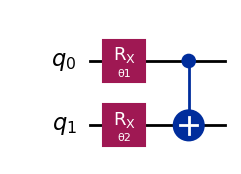

In [153]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

theta1 = Parameter("θ1")
theta2 = Parameter("θ2")

ansatz2q_1 = QuantumCircuit(2)
ansatz2q_1.rx(theta1, 0)
ansatz2q_1.rx(theta2, 1)
ansatz2q_1.cx(0, 1)

ansatz2q_1.draw(output='mpl')

### Energy landscape of our simple ansatz

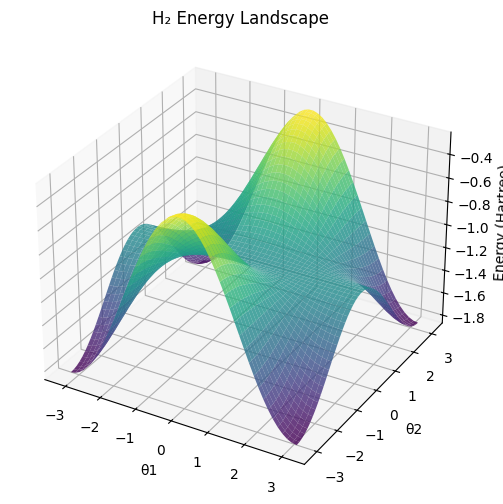

In [154]:
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector

num_points = 50
theta1_vals = np.linspace(-np.pi, np.pi, num_points)
theta2_vals = np.linspace(-np.pi, np.pi, num_points)

energies_2d = np.zeros((num_points, num_points))
ansatz = ansatz2q_1

for i, t1 in enumerate(theta1_vals):
    for j, t2 in enumerate(theta2_vals):
        bind_dict = {theta1: t1, theta2: t2}
        bound_qc = ansatz.assign_parameters(bind_dict)
        state = Statevector.from_instruction(bound_qc)
        energies_2d[i, j] = state.expectation_value(qubit_p_op).real
        

T1, T2 = np.meshgrid(theta1_vals, theta2_vals)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(T1, T2, energies_2d.T, cmap='viridis', alpha=0.8)

ax.set_xlabel("θ1")
ax.set_ylabel("θ2")
ax.set_zlabel("Energy (Hartree)")
ax.set_title("H₂ Energy Landscape")
plt.show()

### We might decide that our system demands more complexity and therefore add more parameters to explore more of the Hilbert space. This naturally comes at the price of increasing computational cost.

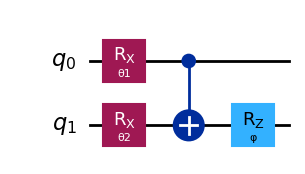

In [155]:
theta1 = Parameter("θ1")
theta2 = Parameter("θ2")
phi = Parameter("φ")

ansatz2q_2 = QuantumCircuit(2)
ansatz2q_2.rx(theta1, 0)
ansatz2q_2.rx(theta2, 1)
ansatz2q_2.cx(0, 1)
ansatz2q_2.rz(phi, 1)

ansatz2q_2.draw(output='mpl')

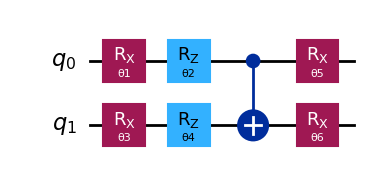

In [156]:
theta1 = Parameter("θ1")
theta2 = Parameter("θ2")
theta3 = Parameter("θ3")
theta4 = Parameter("θ4")
theta5 = Parameter("θ5")
theta6 = Parameter("θ6")

ansatz2q_3 = QuantumCircuit(2)

# First rotation layer
ansatz2q_3.rx(theta1, 0)
ansatz2q_3.rz(theta2, 0)
ansatz2q_3.rx(theta3, 1)
ansatz2q_3.rz(theta4, 1)

# Entanglement
ansatz2q_3.cx(0, 1)

# Second rotation layer
ansatz2q_3.rx(theta5, 0)
ansatz2q_3.rx(theta6, 1)

ansatz2q_3.draw(output='mpl')

## Four qubit ansatz

If we want to solve the more complicated JW mapped form of our hamiltonian, then we need to build a four qubit ansatz. We could build an ansatz circuit in the same way we did for the 2 qubit problem, however qiskit also has prebuilt functions that we can utilize. Efficient SU2 is a commonly-used ansatz.

An efficient_su_2 circuit consists of layers of single qubit operations spanned by SU(2) (special unity group of degree 2, like Pauli rotation gates) and CX entanglements. This is a heuristic pattern that can be useful in variational quantum algorithms like VQE and classification circuits in quantum machine learning (QML).

We'll start with a four-qubit example efficient_su2 circuit with two types of SU(2) gates, say rx and y. We also specify an entanglement scheme and the number of repetitions. 

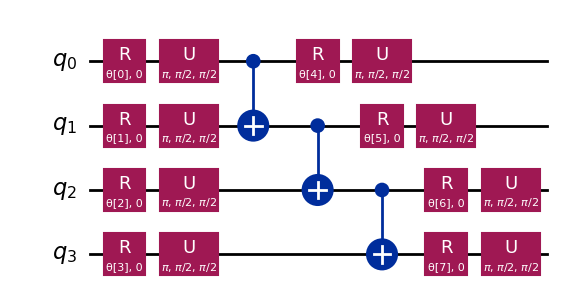

In [157]:
from qiskit.circuit.library import efficient_su2
 
SU2_ansatz = efficient_su2(4, su2_gates=["rx", "y"], entanglement="linear", reps=1)
SU2_ansatz.decompose().draw(output="mpl")

The SU(2) gates appear at the beginning and end with the order and elements as specified in su2_gates = [...]. The entanglement scheme linear means that the CX gates step through the numbered qubits, entangling 0 & 1, then 1 & 2, and so on, down a diagonal line in the circuit. As you might expect, setting reps = 2 simply adds an entanglement layer and an ending SU(2) layer. Settings reps = n corresponds to n entanglement layers, with SU(2) layers between them and on each end.

A generalization of the efficient_su2 is the two-local circuit, which is itself a special case of the n-local circuits. The two-local circuits also contains SU(2) blocks (or rotation blocks) and entanglement blocks. Here, we are free to specify the type of entanglement gates we want to use, for example CRX gates. In this example, all gates accept a parameter, but that need not be the case. One could use Y rotation gates and CX entanglement gates, for example.

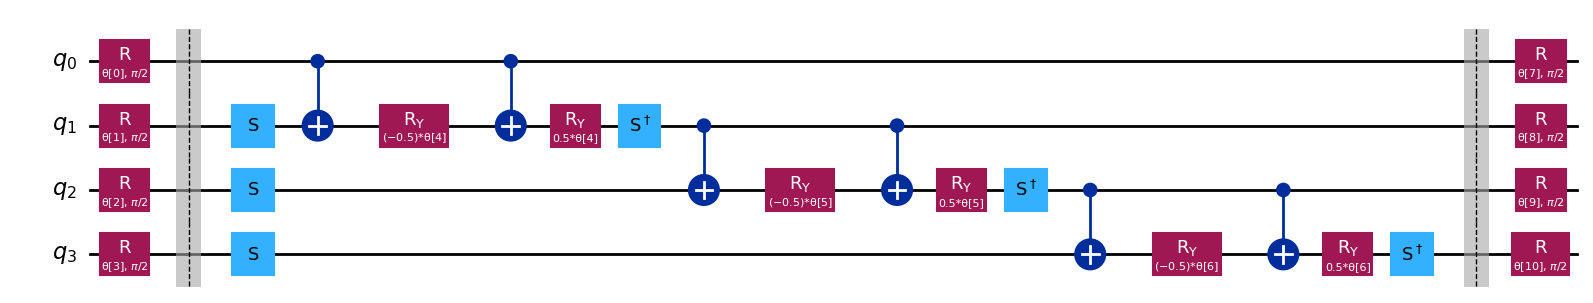

In [158]:
from qiskit.circuit.library import n_local
 
rotation_blocks = ["ry"]
entanglement_blocks = ["crx"]
two_ansatz = n_local(
    4, rotation_blocks, entanglement_blocks, "linear", insert_barriers=True, reps=1
)
two_ansatz.decompose().draw(output="mpl")

# Step 3: Transpile ansatz circuit onto (fake) backend hardware

Backend: {config.backend_name}
Native gates:  ['cx', 'id', 'delay', 'measure', 'reset', 'rz', 'sx', 'x', 'if_else', 'for_loop', 'switch_case'] ,


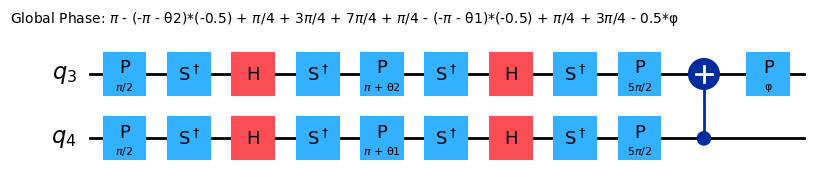

In [159]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

fake_backend = FakeManilaV2() 
noise_model = NoiseModel.from_backend(fake_backend)

backend_sim = AerSimulator(noise_model=noise_model)
config = fake_backend.configuration()
 
print("Backend: {config.backend_name}")
print("Native gates: ", config.supported_instructions, ",")
 
 
target = fake_backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
ansatz=ansatz2q_2

if ansatz.num_qubits != len(h2_hamiltonian.to_list()[0][0]):
    raise ValueError(f"Number of qubits ({ansatz.num_qubits}) in ansatz must" 
                     f"match number of Paulis ({len(h2_hamiltonian.to_list()[0][0])}) in Hamiltonian")

ansatz_isa = pm.run(ansatz)
ansatz_isa.decompose().draw(output="mpl", idle_wires=False)

### During transpilation, Qiskit may remap logical qubits to different physical qubits. Therefore it is important to remap the problem hamiltonian to the new layout

In [160]:
h2_hamiltonian_isa = h2_hamiltonian.apply_layout(layout=ansatz_isa.layout)

# Step 4: Define a cost function

This function computes the energy of the current trial state during the VQE optimization.

It takes the current circuit parameters, prepares the corresponding quantum state using the ansatz, and uses the Estimator to calculate the expectation value of the Hamiltonian — which is the energy of that state.

In [161]:
def cost_func(params, ansatz, hamiltonian, estimator, cost_history_dict):
    """Return estimate of energy from estimator
 
    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        cost_history_dict: Dictionary for storing intermediate results
 
    Returns:
        float: Energy estimate
    """
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]
 
    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)
    print(f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy}]")
 
    return energy

# Step 5: Minimize the hamiltonian expectation value by varying the parameters

In [162]:
from scipy.optimize import minimize
from qiskit_ibm_runtime import EstimatorV2 as Estimator

cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
estimator = Estimator(backend_sim)
estimator.options.default_shots = 10000
 
iterations = 100

# Initial guess
x0 = [0]*len(ansatz.parameters)
x0[0] = 2

res = minimize(
    cost_func,
    x0,
    args=(ansatz_isa, h2_hamiltonian_isa, estimator, cost_history_dict),
    method="cobyla",
    options={"maxiter": iterations, "tol": 1e-12},
)

Iters. done: 1 [Current cost: -1.061138729297234]
Iters. done: 2 [Current cost: -1.058254952206025]
Iters. done: 3 [Current cost: -1.12854849211536]
Iters. done: 4 [Current cost: -1.0620580678795]
Iters. done: 5 [Current cost: -1.1994398826466277]
Iters. done: 6 [Current cost: -1.1540866111989017]
Iters. done: 7 [Current cost: -1.2934754115559004]
Iters. done: 8 [Current cost: -0.8436936719802381]
Iters. done: 9 [Current cost: -1.2975962016951876]
Iters. done: 10 [Current cost: -1.6429103763342088]
Iters. done: 11 [Current cost: -1.461593518098555]
Iters. done: 12 [Current cost: -1.5300509822635004]
Iters. done: 13 [Current cost: -1.674125523250164]
Iters. done: 14 [Current cost: -1.715198191953941]
Iters. done: 15 [Current cost: -1.7688830185403233]
Iters. done: 16 [Current cost: -1.792427886722358]
Iters. done: 17 [Current cost: -1.8067979982501288]
Iters. done: 18 [Current cost: -1.8130339903099482]
Iters. done: 19 [Current cost: -1.8102911191708635]
Iters. done: 20 [Current cost: -

In [163]:
h_vqe = res.fun
parameters = res.x
print("The reference ground state energy is ", min(eigenvalues).real)
print("The computed ground state energy is ", h_vqe)
print("Parameter vector is", parameters)

The reference ground state energy is  -1.8572750302023795
The computed ground state energy is  -1.8208993371774262
Parameter vector is [3.03225753 3.12448488 0.64299569]


You can then bind the optimal parameters to the ansatz which now encodes the orbital occupancies of $H_2$.

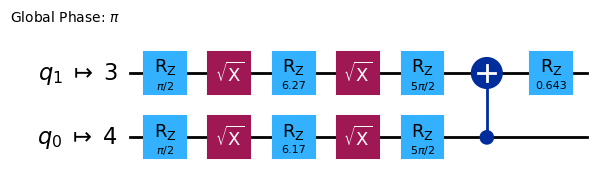

In [164]:
bound_circuit = ansatz_isa.assign_parameters(parameters)
bound_circuit.draw(output='mpl')

# Step 6: Post-processing

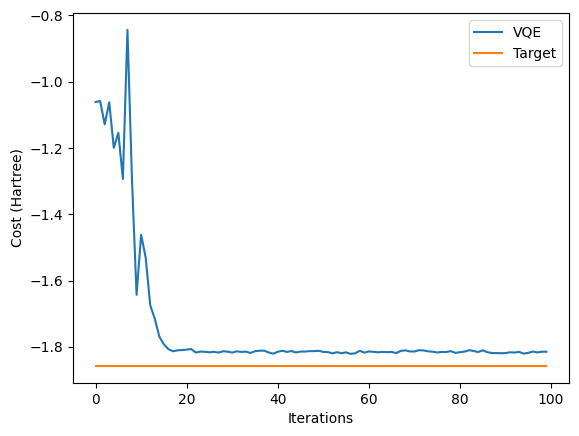

In [165]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
x = np.linspace(0, 10, iterations)
 
# Define the constant function
y_constant = np.full_like(x, min(eigenvalues.real))
ax.plot(
    range(cost_history_dict["iters"]), cost_history_dict["cost_history"], label="VQE"
)
ax.set_xlabel("Iterations")
ax.set_ylabel("Cost (Hartree)")
ax.plot(y_constant, label="Target")
plt.legend()
plt.draw()

# Compare with Qiskit's built-in VQE

You just built VQE from scratch — nice work. But Qiskit also ships a ready-to-use `VQE` class in the `qiskit_algorithms` module. It bundles an ansatz, an optimizer, and an estimator into one convenient interface.

Let's compare our hand-rolled VQE result with the built-in one using the same ansatz and optimizer:

In [166]:
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.circuit.library import EfficientSU2

# Use the same 2-qubit Hamiltonian (from Parity mapping)
h2_hamiltonian = SparsePauliOp.from_list(qubit_p_op.to_list())

# Build a standard ansatz
builtin_ansatz = EfficientSU2(2, reps=1).decompose()

# Set up the built-in VQE
vqe_solver = VQE(
    ansatz=builtin_ansatz, # builtin_ansatz,
    optimizer=COBYLA(maxiter=100),
    estimator=estimator,
    initial_point=[0.5] * builtin_ansatz.num_parameters,
)

# Run it
result = vqe_solver.compute_minimum_eigenvalue(h2_hamiltonian)
print(f"Built-in VQE energy: {result.eigenvalue.real + 0.71997:.6f} Hartree")
print(f"Our VQE energy:      {h_vqe + 0.71997:.6f} Hartree")
print(f"Exact energy:        {min(eigenvalues).real + 0.71997:.6f} Hartree")


/var/folders/_0/25rjhd0j28zb2wxf95gymb180000gn/T/ipykernel_43160/73903086.py:9: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  builtin_ansatz = EfficientSU2(2, reps=1).decompose()


Built-in VQE energy: -1.076402 Hartree
Our VQE energy:      -1.100929 Hartree
Exact energy:        -1.137305 Hartree


---

## Beyond this course

We've implemented VQE from the ground up and we now know the core pattern of variational quantum algorithms:

1. Build a Hamiltonian (typically the hard part)
2. Design an ansatz 
3. Measure 
4. Optimize 
5. Repeat

This same pattern shows up a lot in classical-quantum hybrid algorithms. 

Here are some directions Qiskit can take you next:

| Topic | What it does | Where to start |
|-------|-------------|----------------|
| **QAOA** | Solves combinatorial optimization problems (like Max-Cut, traveling salesman) | [Qiskit QAOA tutorial](https://quantum.cloud.ibm.com/docs/en/tutorials/quantum-approximate-optimization-algorithm) |
| **Quantum Machine Learning** | Trains parameterized circuits as classifiers or generative models | [Qiskit Machine Learning](https://quantum.cloud.ibm.com/learning/en/courses/quantum-machine-learning/introduction) |
| **Phase Estimation** | Measures eigenvalues of a unitary operator — the backbone of Shor's algorithm | [Qiskit phase estimation](https://quantum.cloud.ibm.com/learning/en/courses/utility-scale-quantum-computing/quantum-phase-estimation) |
| **Qiskit Optimization** | Applies QAOA and other solvers to real-world optimization problems | [Qiskit Optimization docs](https://qiskit-community.github.io/qiskit-optimization/tutorials/index.html/) |

---
---

# Appendix

# LiH

In [ ]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer

# Define the molecule
driver = PySCFDriver(
    atom="Li 0 0 0; H 0 0 1.6",
    basis="sto3g",
)

problem = driver.run()
fermionic_op = problem.hamiltonian.second_q_op()
print(fermionic_op)

Fermionic Operator
number spin orbitals=12, number terms=1860
  -4.727393127817873 * ( +_0 -_0 )
+ 0.1054996779156695 * ( +_0 -_1 )
+ 0.16696140774524515 * ( +_0 -_2 )
+ -0.03467720425650058 * ( +_0 -_5 )
+ 0.10549967791566937 * ( +_1 -_0 )
+ -1.492646221720883 * ( +_1 -_1 )
+ 0.03289282731067744 * ( +_1 -_2 )
+ -0.05270787773815798 * ( +_1 -_5 )
+ 0.1669614077452452 * ( +_2 -_0 )
+ 0.03289282731067722 * ( +_2 -_1 )
+ -1.125544737709696 * ( +_2 -_2 )
+ 0.03044557204107766 * ( +_2 -_5 )
+ -1.1357998501303823 * ( +_3 -_3 )
+ -1.135799850130383 * ( +_4 -_4 )
+ -0.03467720425650048 * ( +_5 -_0 )
+ -0.05270787773815781 * ( +_5 -_1 )
+ 0.03044557204107773 * ( +_5 -_2 )
+ -0.9509665919933249 * ( +_5 -_5 )
+ -4.727393127817873 * ( +_6 -_6 )
+ 0.1054996779156695 * ( +_6 -_7 )
+ 0.16696140774524515 * ( +_6 -_8 )
+ -0.03467720425650058 * ( +_6 -_11 )
+ 0.10549967791566937 * ( +_7 -_6 )
+ -1.492646221720883 * ( +_7 -_7 )
+ 0.03289282731067744 * ( +_7 -_8 )
+ -0.05270787773815798 * ( +_7 -_11 )
+ 0

In [ ]:
mapper = JordanWignerMapper()
qubit_jw_op = mapper.map(fermionic_op)

for pauli, coeff in qubit_jw_op.to_list():
    print(f"{pauli}  {coeff.real}")

print(f"Number of terms: {len(qubit_jw_op.to_list())}\n"
      f"Number of qubits: {len(qubit_jw_op.to_list()[0][0])}")

IIIIIIIIIIII  -5.128074449940943
IIIIIIIIIIIZ  1.0064988767033274
IIIIIIIIIIYY  0.014319294514924946
IIIIIIIIIIXX  0.014319294514924946
IIIIIIIIIYZY  0.02534772990345472
IIIIIIIIIXZX  0.02534772990345472
IIIIIIYZZZZY  -0.0016662986505464996
IIIIIIXZZZZX  -0.0016662986505464996
IIIIIIIIIIZI  -0.11846053900005071
IIIIIIIIIYYI  -0.007477511052700785
IIIIIIIIIXXI  -0.007477511052700785
IIIIIIYZZZYI  0.005309225832518739
IIIIIIXZZZXI  0.005309225832518739
IIIIIIIIIZII  -0.19809729990208214
IIIIIIYZZYII  0.014686660276420396
IIIIIIXZZXII  0.014686660276420396
IIIIIIIIZIII  -0.23046822629623392
IIIIIIIZIIII  -0.23046822629623406
IIIIIIZIIIII  -0.3850053250190655
IIIIIZIIIIII  1.0064988767033278
IIIIYYIIIIII  0.014319294514924967
IIIIXXIIIIII  0.014319294514924967
IIIYZYIIIIII  0.025347729903454706
IIIXZXIIIIII  0.025347729903454706
YZZZZYIIIIII  -0.0016662986505464913
XZZZZXIIIIII  -0.0016662986505464913
IIIIZIIIIIII  -0.11846053900005082
IIIYYIIIIIII  -0.007477511052700787
IIIXXIIIIIII  -0.0

In [ ]:
# Keep 2 electrons in 2 spatial orbitals
active_space = ActiveSpaceTransformer(
    num_electrons=2,
    num_spatial_orbitals=2,
)
transformed_problem = active_space.transform(problem)

fermionic_op = transformed_problem.hamiltonian.second_q_op()
print(fermionic_op)

Fermionic Operator
number spin orbitals=4, number terms=72
  -0.7725817191195227 * ( +_0 -_0 )
+ 0.04857960498558664 * ( +_0 -_1 )
+ 0.048579604985586416 * ( +_1 -_0 )
+ -0.3559395442578684 * ( +_1 -_1 )
+ -0.7725817191195227 * ( +_2 -_2 )
+ 0.04857960498558664 * ( +_2 -_3 )
+ 0.048579604985586416 * ( +_3 -_2 )
+ -0.3559395442578684 * ( +_3 -_3 )
+ 0.24365548336622173 * ( +_0 +_0 -_0 -_0 )
+ -0.024289796135626585 * ( +_0 +_0 -_1 -_0 )
+ -0.024289796135626585 * ( +_0 +_1 -_0 -_0 )
+ 0.11180502239530334 * ( +_0 +_1 -_1 -_0 )
+ 0.24365548336622173 * ( +_0 +_2 -_2 -_0 )
+ -0.024289796135626585 * ( +_0 +_2 -_3 -_0 )
+ -0.024289796135626585 * ( +_0 +_3 -_2 -_0 )
+ 0.11180502239530334 * ( +_0 +_3 -_3 -_0 )
+ -0.024289796135626585 * ( +_0 +_0 -_0 -_1 )
+ 0.006531991790404015 * ( +_0 +_0 -_1 -_1 )
+ 0.006531991790404015 * ( +_0 +_1 -_0 -_1 )
+ 0.003742086037511999 * ( +_0 +_1 -_1 -_1 )
+ -0.024289796135626585 * ( +_0 +_2 -_2 -_1 )
+ 0.006531991790404015 * ( +_0 +_2 -_3 -_1 )
+ 0.006531991790404

In [ ]:
mapper = JordanWignerMapper()
qubit_jw_op = mapper.map(fermionic_op)

for pauli, coeff in qubit_jw_op.to_list():
    print(f"{pauli}  {coeff.real}")

print(f"Number of terms: {len(qubit_jw_op.to_list())}\n"
      f"Number of qubits: {len(qubit_jw_op.to_list()[0][0])}")

IIII  -0.7051449008248359
IIIZ  0.15592409137654922
IIYY  0.014015947443735967
IIXX  0.014015947443735967
IIZI  -0.01503982224040858
IZII  0.15592409137654917
YYII  0.014015947443735967
XXII  0.014015947443735967
ZIII  -0.015039822240408559
IIZZ  0.05263651530244966
IZIZ  0.12182774168311086
YYIZ  0.012144898067813293
XXIZ  0.012144898067813293
ZIIZ  0.05590251119765167
IZYY  0.012144898067813293
IZXX  0.012144898067813293
YYYY  0.0032659958952020074
XXYY  0.0032659958952020074
YYXX  0.0032659958952020074
XXXX  0.0032659958952020074
ZIYY  -0.0018710430187559995
ZIXX  -0.0018710430187559995
IZZI  0.05590251119765167
YYZI  -0.0018710430187559995
XXZI  -0.0018710430187559995
ZIZI  0.08447056786924144
ZZII  0.05263651530244966
Number of terms: 27
Number of qubits: 4


In [ ]:
# Map to qubits using Jordan-Wigner
mapper = JordanWignerMapper()
qubit_op = mapper.map(fermionic_op)

lih_hamiltonian = SparsePauliOp.from_list(qubit_op.to_list())

builtin_ansatz = EfficientSU2(4, reps=2).decompose()

# Set up the built-in VQE
vqe_solver = VQE(
    ansatz=builtin_ansatz, # builtin_ansatz,
    optimizer=COBYLA(maxiter=100),
    estimator=estimator,
    initial_point=[0.5] * builtin_ansatz.num_parameters,
)

result = vqe_solver.compute_minimum_eigenvalue(lih_hamiltonian)
print(f"Built-in VQE energy: {result.eigenvalue.real + 0.71997:.6f} Hartree")


/var/folders/_0/25rjhd0j28zb2wxf95gymb180000gn/T/ipykernel_43160/845682923.py:18: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  builtin_ansatz = EfficientSU2(4, reps=2).decompose()


Built-in VQE energy: -0.212282 Hartree


In [ ]:
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA

# Noiseless backend + estimator
backend_clean = AerSimulator()
estimator_clean = Estimator(backend_clean)

# Run built-in VQE on LiH
vqe_lih = VQE(
    ansatz=SU2_ansatz,
    optimizer=COBYLA(maxiter=100),
    estimator=estimator_clean,
    initial_point=[0.0] * SU2_ansatz.num_parameters,
)

result_lih = vqe_lih.compute_minimum_eigenvalue(lih_hamiltonian)

exact_lih = min(eigenvalues).real
print(f"Exact (diagonalization):  {exact_lih:.6f} Hartree")
print(f"Built-in VQE (noiseless): {result_lih.eigenvalue.real:.6f} Hartree")

Exact (diagonalization):  -1.058117 Hartree
Built-in VQE (noiseless): -0.974678 Hartree


In [ ]:
H = np.array(lih_hamiltonian)
eigenvalues, eigenvectors = np.linalg.eig(H)
print(min(eigenvalues))

(-1.058116535136541+0j)
